In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

import matplotlib as mpl
import emcee
import corner
from getdist import MCSamples, plots
import scipy

In [2]:
mpl.rcParams['font.size'] = 12  # Taille générale
mpl.rcParams['axes.titlesize'] = 16  # Taille des titres des graphiques
mpl.rcParams['axes.labelsize'] = 14  # Taille des labels des axes
mpl.rcParams['xtick.labelsize'] = 12  # Taille des étiquettes de l'axe x
mpl.rcParams['ytick.labelsize'] = 12  # Taille des étiquettes de l'axe y
mpl.rcParams['legend.fontsize'] = 12  # Taille de la légende
mpl.rcParams['figure.titlesize'] = 18  # Taille du titre de la figure

In [3]:
galaxy1="NGC5128_CenA"
galaxy2="NGC5236_M83"
r=0.76
CoM_Name="CoM_CenA_M83_0.76"
row_name=CoM_Name


In [4]:
file_path = 'data/data_'+CoM_Name+'_lg.csv'

galaxy_df = pd.read_csv(file_path)

In [5]:
df=galaxy_df
mask = ~df['Name'].str.startswith('CoM_')
G = 4.3009e-9  # Constante gravitationnelle en (km/s)² Mpc / M☉

# Minor Infall

In [6]:
def velocity_model_1(r, H0, M ,derivative=False):
    Omega_Lambda = 0.67

    # Avoid numerical issues with the square root
    if M <= 0:
        return np.full_like(r, np.nan)  # avoid sqrt of negative mass
    
    term1 = H0 * (1.1 + 0.31 * Omega_Lambda) * r
    
    # Check if the term inside sqrt will be negative
    sqrt_term = G * M / r
    valid_points = sqrt_term > 0
    
    result = np.full_like(r, np.nan)
    if np.any(valid_points):
        result[valid_points] = term1[valid_points] - 1.1 * np.sqrt(sqrt_term[valid_points])
    if not derivative:    
        return result
    else:
        result_derivative = np.full_like(r, np.nan)
        result_derivative[valid_points] = H0 * (1.1 + 0.31 * Omega_Lambda) + (1.1/2) * np.sqrt(sqrt_term[valid_points]) / r[valid_points]
        return (result,result_derivative)


In [7]:
def velocity_model_2(r, H0, M):
    G = 4.3009e-9   # constante gravitationnelle en m^3 kg^-1 s^-2
    n = 0.702

    r = np.array(r, dtype=np.float64)

    # Éviter les divisions par zéro ou racines de valeurs négatives
    r_safe = np.where(r == 0, np.nan, r)

    # Terme 1 : - (0.940 * H0 / R^n) * (GM / H0^2)^((n+1)/3)
    factor1 = -0.940 * H0 / np.power(r_safe, n)
    factor2 = np.power((G * M) / (H0 ** 2), (n + 1) / 3)

    term1 = factor1 * factor2

    # Terme 2 : + 1.335 * H0 * R
    term2 = 1.335 * H0 * r

    # Vitesse totale
    v = term1 + term2

    return v

In [8]:
def analyze_velocity_model(df, mask,velocity, row_name,velocity_model, xmin=1,xmax=15,plot=True):
    # -------------------
    # 1. Data preparation
    # -------------------
    df_clean = df.loc[mask, [
        'dis_center_' + row_name,
        velocity + '_' + row_name,
        'e_dis_center_min_' + row_name,
        'e_dis_center_max_' + row_name,
        'e_'+velocity+'_min_' + row_name,
        'e_'+velocity+'_max_' + row_name
    ]].apply(pd.to_numeric, errors='coerce').dropna()

    x = df_clean['dis_center_' + row_name].values
    y = df_clean[velocity+'_' + row_name].values

    xerr_low_full = df_clean['e_dis_center_min_' + row_name].values
    xerr_high_full = df_clean['e_dis_center_max_' + row_name].values
    yerr_low_full = df_clean['e_'+velocity+'_min_' + row_name].values
    yerr_high_full = df_clean['e_'+velocity+'_max_' + row_name].values

    # Apply the (0.5 <= x <= 5) mask uniformly
    mask_fit = (x >= xmin) & (x <= xmax) & (np.absolute(y-x*70) < 400)
    x = x[mask_fit]
    y = y[mask_fit]
    xerr_low = xerr_low_full[mask_fit]
    xerr_high = xerr_high_full[mask_fit]
    yerr_low = yerr_low_full[mask_fit]
    yerr_high = yerr_high_full[mask_fit]
    
    # Calculate symmetrized errors for MCMC (missing in original)
    xerr_sym = (xerr_low + xerr_high) / 2
    yerr_sym = (yerr_low + yerr_high) / 2

    # -------------------
    # 2. Define the model
    # -------------------

    # -------------------
    # 3. Log-likelihood
    # -------------------
    def total_velocity_error(r, v_err, r_err, H0, M):
        # Calculate the derivative df/dx numerically
        dr = 1e-5 * r  # small relative step
        f_plus = velocity_model(r + dr, H0, M)
        f_minus = velocity_model(r - dr, H0, M)
        df_dx = (f_plus - f_minus) / (2 * dr)

        # Now compute total error
        return np.sqrt(v_err**2 + (df_dx * r_err)**2)

    def log_likelihood(theta, r, r_err, v, v_err):
        H0, M = theta
        model = velocity_model(r, H0, M)
        if not np.all(np.isfinite(model)):
            return -np.inf
    
        # Total error including propagated uncertainty from r
        v_total_err = total_velocity_error(r, v_err, r_err, H0, M)
        if not np.all(np.isfinite(v_total_err)) or np.any(v_total_err == 0):
            return -np.inf
    
        return -0.5 * np.sum(((v - model) / v_total_err)**2  + np.log(2 * np.pi * v_total_err**2))
    
    # def log_likelihood(theta, r, r_err, v, v_err):
    #     H0, M = theta
    #     
    #     # Modèle et dérivée du modèle
    #     model, derivative_model = velocity_model(r, H0, M, derivative=True)
    #     
    #     if not np.all(np.isfinite(model)) or not np.all(np.isfinite(derivative_model)):
    #         return -np.inf
    #     
    #     # Distance minimale au carré entre les points et la courbe
    #     dmin2 = np.array([
    #         distance_min_curve_optimized(ri, vi, f=lambda x: velocity_model(x, H0, M))[0]**2
    #         for ri, vi in zip(r, v)
    #     ])
    #     
    #     # Erreur totale propagée
    #     sigma2 = v_err**2 + (derivative_model * r_err)**2
    #     
    #     if not np.all(np.isfinite(sigma2)) or np.any(sigma2 == 0):
    #         return -np.inf
    #     
    #     return -0.5 * np.sum(dmin2 / sigma2 + np.log(2 * np.pi * sigma2))

    def log_prior(theta,H0_prior=False,M_prior=False):
        H0, M = theta
        if H0_prior:
            if 1e11 < M < 1e14:
                logp_H0 = -0.5 * ((H0 - 73) / 1.0)**2 - np.log(np.sqrt(2 * np.pi) * 1.0)
                return logp_H0
            return -np.inf
        
        elif M_prior:
            
            if 30 < H0 < 90 and M > 0:
                # Gaussian prior on M: mean=3e12, sigma=1e12
                logp_M = -0.5 * ((M - 3e12) / 1e12)**2 - np.log(np.sqrt(2 * np.pi) * 1e12)
                return logp_M
        else:
            if 30 < H0 < 150 and 1e11 < M < 1e14:
                return 0.0  # flat prior
            return -np.inf  # log(0)
        return -np.inf

    def log_probability(theta, r, r_err, v, v_err):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        return lp + log_likelihood(theta, r, r_err, v, v_err)

    # -------------------
    # 4. Run MCMC
    # -------------------
    ndim = 2
    nwalkers = 32
    p0 = np.array([70, 1e12]) + 2e-4 * np.random.randn(nwalkers, ndim)

    sampler_min = emcee.EnsembleSampler(nwalkers, ndim, log_probability, 
                                     args=(x, xerr_sym, y, yerr_sym))
    sampler_min.run_mcmc(p0, 5000, progress=True)

    # Get the flat samples (renamed from the original)
    samples_min = sampler_min.get_chain(discard=1000, thin=15, flat=True)

    # -------------------
    # 5. Use GetDist for posterior plots
    # -------------------
    if plot:
        names = ['H0', 'M']
        labels = [r'H_0', r'M \,[kg]']  # LaTeX labels

        # Create MCSamples object from your MCMC samples
        gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)

        # Create the triangle plot
        g = plots.get_subplot_plotter()
        g.triangle_plot(gdsamples_min, filled=True)
        plt.show()

        # -------------------
        # 6. Plot best-fit model
        # -------------------
        H0_mcmc, M_mcmc = np.median(samples_min, axis=0)


        H0_lower, M_lower = np.percentile(samples_min, 16, axis=0)
        H0_upper, M_upper = np.percentile(samples_min, 84, axis=0)

        # Compute uncertainties
        H0_uncertainty = 0.5 * (H0_upper - H0_lower)
        M_uncertainty = 0.5 * (M_upper - M_lower)

        # Fine grid
        r_plot = np.linspace(xmin, 15, 500)
        v_median = velocity_model(r_plot, H0_mcmc, M_mcmc)

        # Sample 100 posterior draws to make uncertainty band
        v_samples_min = np.array([velocity_model(r_plot, h0, m) for h0, m in samples_min[np.random.choice(len(samples_min), 1000, replace=False)]])

        v_lower = np.percentile(v_samples_min, 0.15, axis=0)
        v_upper = np.percentile(v_samples_min, 99.15, axis=0)

        # Plot
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.errorbar(x, y, xerr=[xerr_low, xerr_high], yerr=[yerr_low, yerr_high],
                    fmt='o', color='black', ecolor='red', capsize=5, label='Data')

        ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))
        ax.fill_between(r_plot, v_lower, v_upper, color='blue', alpha=0.3, label=rf"$3\sigma$ credible interval")

        ax.set_xlabel("Distance from CoM (Mpc)")
        ax.set_ylabel(r"$v{r}$ (km/s)")
        ax.grid(True)
        ax.set_xlim(0, 15)
        ax.set_ylim(-300, 1000)
        ax.legend()
        plt.plot()
        return H0_mcmc, H0_uncertainty, M_mcmc, M_uncertainty, samples_min
    else:
        H0_mcmc, M_mcmc = np.median(samples_min, axis=0)
        H0_lower, M_lower = np.percentile(samples_min, 16, axis=0)
        H0_upper, M_upper = np.percentile(samples_min, 84, axis=0)
        H0_uncertainty = 0.5 * (H0_upper - H0_lower)
        M_uncertainty = 0.5 * (M_upper - M_lower)
        return H0_mcmc, H0_uncertainty, M_mcmc, M_uncertainty, samples_min

In [9]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_model_fitted(velocity,velocity_model,mask,H0,H0_sigma,M,M_sigma):
    def velocity_model(r, H0, M):
        Omega_Lambda = 0.67
        term1 = H0 * (1.1 + 0.31 * Omega_Lambda) * r
        term2 = 1.1 * np.sqrt(G * M / r)  
        return term1 - term2

    # === DISTANCES POUR COURBE THÉORIQUE ===
    r = np.linspace(0.5, 15, 300)
    v_r = velocity_model(r, H0, M)

    # Vitesse min/max pour zone d'incertitude
    v_r_min = velocity_model(r, H0 - H0_sigma, M - M_sigma)
    v_r_max = velocity_model(r, H0 + H0_sigma, M + M_sigma)

    # === EXTRACTION DES DONNÉES ===
    x = pd.to_numeric(df.loc[mask, 'dis_center_' + row_name], errors='coerce').values
    y = pd.to_numeric(df.loc[mask, velocity+"_" + row_name], errors='coerce').values
    names = df.loc[mask, 'Name'].astype(str).values  # Nom des galaxies

    fig, ax = plt.subplots(1, 1, figsize=(12, 10))

    # === ERREURS SUR DONNÉES ===
    col_e_x_max = 'e_dis_center_max_' + row_name
    col_e_x_min = 'e_dis_center_min_' + row_name
    col_e_y_max = 'e_'+velocity+'_max_' + row_name
    col_e_y_min = 'e_'+velocity+'_min_' + row_name

    if all(col in df.columns for col in [col_e_x_max, col_e_x_min, col_e_y_max, col_e_y_min]):
        e_x_min = pd.to_numeric(df.loc[mask, col_e_x_min], errors='coerce').values
        e_x_max = pd.to_numeric(df.loc[mask, col_e_x_max], errors='coerce').values
        e_y_min = pd.to_numeric(df.loc[mask, col_e_y_min], errors='coerce').values
        e_y_max = pd.to_numeric(df.loc[mask, col_e_y_max], errors='coerce').values

        # === TRAITEMENT DES GALAXIES SPECIALES ===
        special_mask = np.array(["cena" in name.lower() or "M83" in name.upper() for name in names])
        normal_mask = ~special_mask

        # Galaxies normales : ronds
        ax.errorbar(
            x[normal_mask], y[normal_mask],
            xerr=[e_x_min[normal_mask], e_x_max[normal_mask]],
            yerr=[e_y_min[normal_mask], e_y_max[normal_mask]],
            fmt='o', color='black', capsize=5, ecolor='red', label="Data"
        )

        # Galaxies spéciales : étoiles
        ax.errorbar(
            x[special_mask], y[special_mask],
            xerr=[e_x_min[special_mask], e_x_max[special_mask]],
            yerr=[e_y_min[special_mask], e_y_max[special_mask]],
            fmt='*', color='orange', capsize=5, ecolor='orange', markersize=20, label="CenA / M83"
        )

    # === COURBE THÉORIQUE + INCERTITUDE ===
    ax.plot(r, v_r, label=rf"Fit: $H_0 = {H0:.1f} \pm {H0_sigma:.1f}$"+ "\n"+ rf"$M = ({M/1e12:.2f} \pm {M_sigma/1e12:.2f}) \times 10^{{12}}\, M_\odot$", color='green')
    ax.fill_between(r, v_r_min, v_r_max, color='green', alpha=0.3, label="uncertainties")

    # === MISE EN FORME ===
    ax.set_xlabel("Distance from CoM (Mpc)")
    ax.set_ylabel(r"$v_r$ (km/s)")
    ax.set_xlim(0, 14)
    ax.set_ylim(-500, 1500)
    ax.grid(True)
    ax.legend()
    plt.show()


In [10]:
def plot_fit_max_dist(df,mask,row_name,velocity,velocity_model,xmin,xminmax,xmaxmax,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmax, xmaxmax, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma, _ = analyze_velocity_model(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=xmin,xmax=k,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

In [11]:
def plot_fit_min_dist(df,mask,row_name,velocity,velocity_model,xmax,xminmin,xmaxmin,Nb_point):

    # Vecteur r (de 0 à 4, 10 points)
    r_plot = np.linspace(xminmin, xmaxmin, Nb_point)

    H_values = []
    H_sigmas = []
    M_values = []
    M_sigmas = []
    # Remplissage des valeurs
    for k in r_plot:
        H0, H0_sigma, M , M_sigma, _ = analyze_velocity_model(df=df, mask=mask, row_name=row_name,velocity=velocity,velocity_model=velocity_model, xmin=k,xmax=xmax,plot= False)
        H_values.append(H0)
        H_sigmas.append(H0_sigma)
        M_values.append(M)
        M_sigmas.append(M_sigma)

    # Création de la figure
    fig, ax1 = plt.subplots()

    # Axe primaire pour H
    ax1.set_xlabel("r")
    ax1.set_ylabel("H", color="tab:blue")
    ax1.plot(r_plot, H_values, marker='o', color="tab:blue", label="H")
    ax1.fill_between(r_plot,
                     np.array(H_values) - np.array(H_sigmas),
                     np.array(H_values) + np.array(H_sigmas),
                     color="tab:blue", alpha=0.2, label="H uncertainty")
    ax1.tick_params(axis='y', labelcolor="tab:blue")

    # Axe secondaire pour M
    ax2 = ax1.twinx()
    ax2.set_ylabel("M", color="tab:red")
    ax2.plot(r_plot, M_values, marker='s', linestyle='--', color="tab:red", label="M")
    ax2.fill_between(r_plot,
                     np.array(M_values) - np.array(M_sigmas),
                     np.array(M_values) + np.array(M_sigmas),
                     color="tab:red", alpha=0.2, label="M uncertainty")
    ax2.tick_params(axis='y', labelcolor="tab:red")

    # Titre et mise en page
    plt.title("Évolution de H et M en fonction de r")
    fig.tight_layout()

    # Affichage du graphique
    plt.show()

100%|██████████| 5000/5000 [00:16<00:00, 310.27it/s]


Removed no burn in


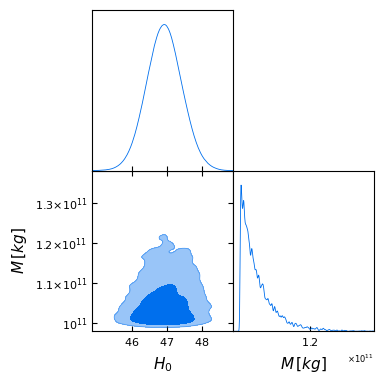

C:\Users\Adrian\AppData\Local\Temp\ipykernel_29732\1371389369.py:171: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot(r_plot, v_median, 'r-', color='blue',label=(rf"Fit: $H_0 = {H0_mcmc:.1f} \pm {H0_uncertainty:.1f}$"+ "\n"+ rf"$M = ({M_mcmc/1e12:.2f} \pm {M_uncertainty/1e12:.2f}) \times 10^{{12}}\, M_\odot$"))


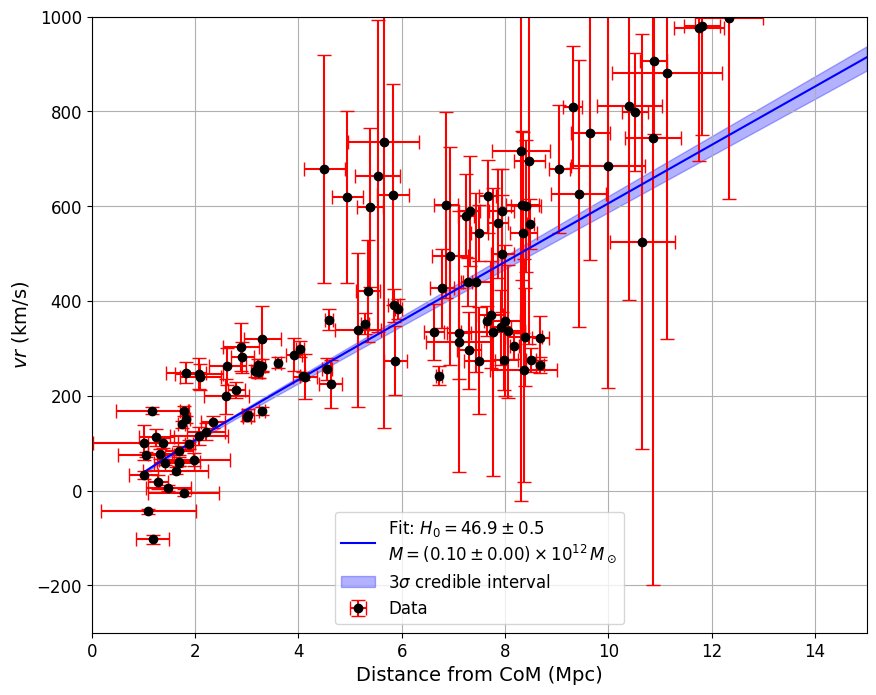

In [12]:
H0_min, H0_sigma_min, M_min, M_sigma_min, samples_min = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1, xmin=1, xmax=15)

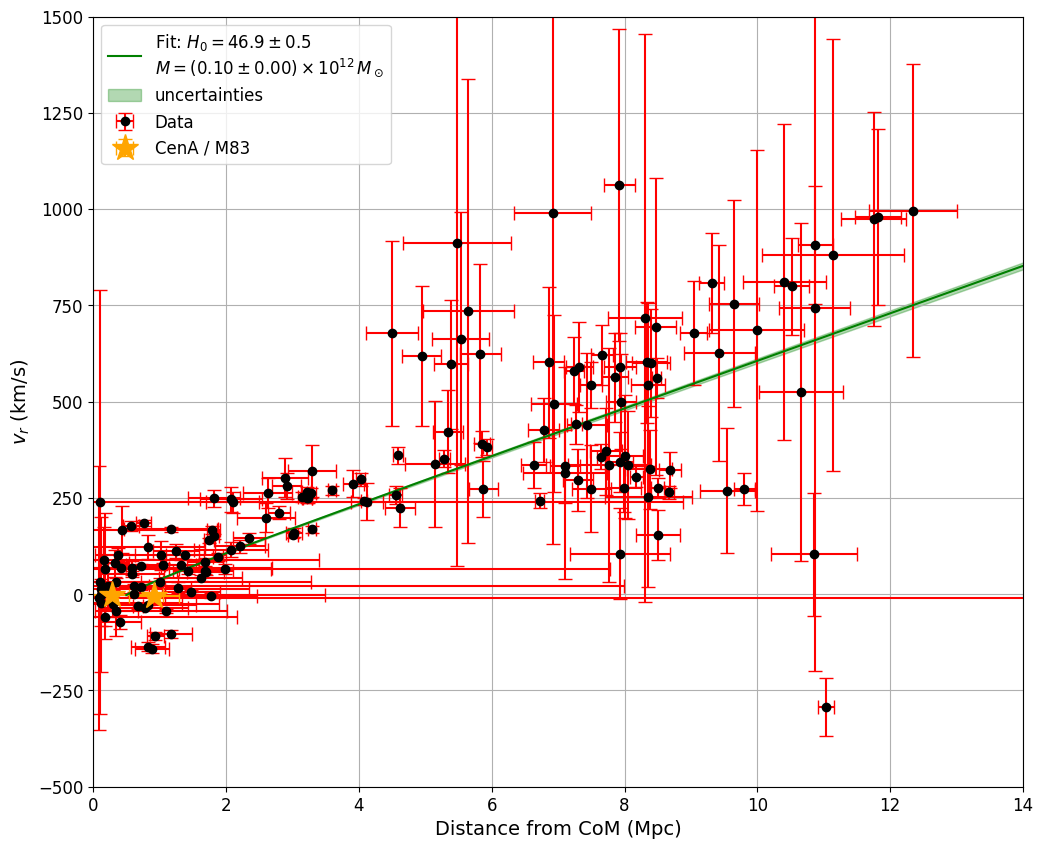

In [13]:
plot_model_fitted(velocity='minor_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_min,H0_sigma=H0_sigma_min,M=M_min,M_sigma=M_sigma_min)

# Major infall

In [14]:
H0_maj, H0_sigma_maj, M_maj, M_sigma_maj, samples_maj = analyze_velocity_model(df=df, mask= mask,row_name= row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1, xmin=1, xmax=15)

  5%|▌         | 272/5000 [00:01<00:18, 259.43it/s]


KeyboardInterrupt: 

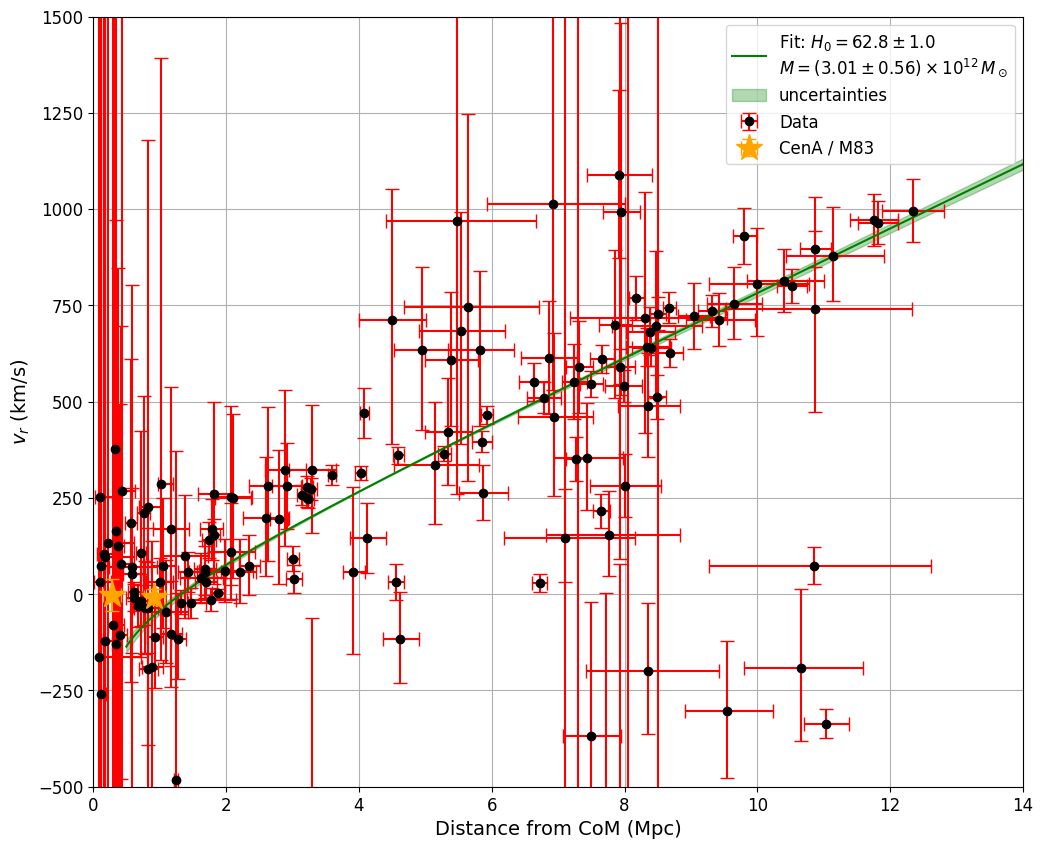

In [ ]:
plot_model_fitted(velocity='major_infall_velocity',velocity_model=velocity_model_1,mask=mask,H0=H0_maj,H0_sigma=H0_sigma_maj,M=M_maj,M_sigma=M_sigma_maj)

Removed no burn in
Removed no burn in


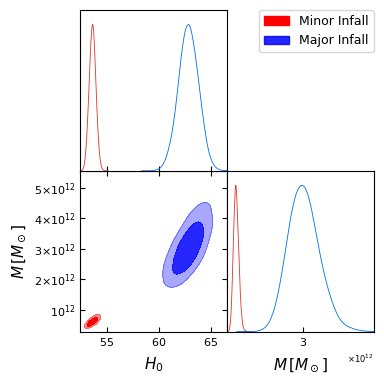

=== Résultats Minor Infall ===
H0 = 53.63 ± 0.32
M = (0.59 ± 0.09) × 10^12 M_☉

=== Résultats Major Infall ===
H0 = 62.85 ± 0.96
M = (3.01 ± 0.56) × 10^12 M_☉


In [ ]:
# Définition des noms et labels cohérents
names = ['H0', 'M']
labels = [r'H_0', r'M \,[M_\odot]']  # Utiliser M_☉ (masse solaire) pour être cohérent

# Créer les objets MCSamples pour les deux analyses
gdsamples_min = MCSamples(samples=samples_min, names=names, labels=labels)
gdsamples_maj = MCSamples(samples=samples_maj, names=names, labels=labels)

# Créer le triangle plot avec les deux distributions
g = plots.get_subplot_plotter()
g.triangle_plot([gdsamples_min, gdsamples_maj], 
                filled=True, 
                legend_labels=['Minor Infall', 'Major Infall'],
                colors=['red', 'blue'])  # Ajouter des couleurs différentes pour mieux distinguer

plt.show()

# Optionnel : afficher les résultats numériques
print("=== Résultats Minor Infall ===")
print(f"H0 = {H0_min:.2f} ± {H0_sigma_min:.2f}")
print(f"M = ({M_min/1e12:.2f} ± {M_sigma_min/1e12:.2f}) × 10^12 M_☉")

print("\n=== Résultats Major Infall ===")
print(f"H0 = {H0_maj:.2f} ± {H0_sigma_maj:.2f}")
print(f"M = ({M_maj/1e12:.2f} ± {M_sigma_maj/1e12:.2f}) × 10^12 M_☉")
plt.show()

In [ ]:
plot_fit_max_dist(df=df,mask=mask,row_name=row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1,xmin=1,xminmax=3,xmaxmax=15,Nb_point=12)

 58%|█████▊    | 2883/5000 [00:10<00:06, 303.03it/s]

100%|██████████| 5000/5000 [00:16<00:00, 296.24it/s]


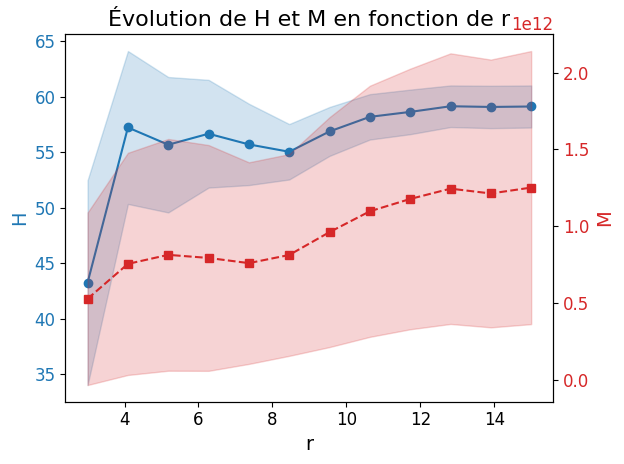

In [ ]:
plot_fit_max_dist(df=df,mask=mask,row_name=row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1,xmin=1,xminmax=3,xmaxmax=15,Nb_point=12)

100%|██████████| 5000/5000 [00:15<00:00, 322.44it/s]


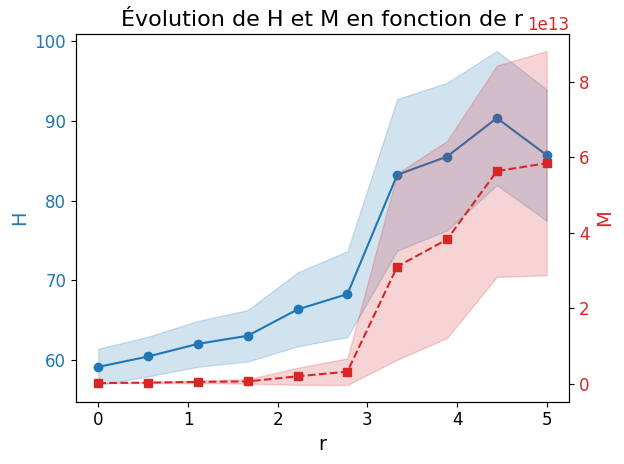

In [ ]:
plot_fit_min_dist(df=df,mask=mask,row_name=row_name,velocity='minor_infall_velocity',velocity_model=velocity_model_1,xmax=7,xminmin=0,xmaxmin=5,Nb_point=10)

100%|██████████| 5000/5000 [00:13<00:00, 365.26it/s]


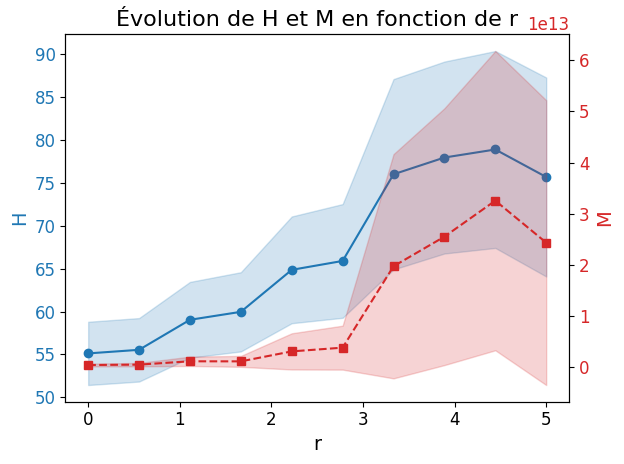

In [ ]:
plot_fit_min_dist(df=df,mask=mask,row_name=row_name,velocity='major_infall_velocity',velocity_model=velocity_model_1,xmax=7,xminmin=0,xmaxmin=5,Nb_point=10)